In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: mps


In [16]:
def data_loader(
            data_dir: str,
            batch_size: int,
            random_seed: int = 42,
            valid_size: float = 0.1,
            shuffle: bool = True,
            test: bool = False,
            image_size: int = 128,
            max_train_samples=None,
            max_valid_samples=None,
            max_test_samples=None,
    ):
    """
        This is the data loader class
        Returns:
            training or test data based on the arguments
    """
    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )
    # define transforms
    transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            normalize,
    ])
    pin_memory = device.type == 'cuda'
    if test:
        dataset = datasets.CIFAR10(
          root=data_dir, train=False,
          download=True, transform=transform,
        )
        if max_test_samples is not None:
            dataset = torch.utils.data.Subset(
                dataset, list(range(min(max_test_samples, len(dataset))))
            )
        data_loader = torch.utils.data.DataLoader(
            dataset, batch_size=batch_size, shuffle=shuffle, pin_memory=pin_memory
        )
        return data_loader
    # load the dataset
    train_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=transform,
    )
    valid_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=transform,
    )
    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))
    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)
    train_idx, valid_idx = indices[split:], indices[:split]
    if max_train_samples is not None:
        train_idx = train_idx[:max_train_samples]
    if max_valid_samples is not None:
        valid_idx = valid_idx[:max_valid_samples]
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, sampler=train_sampler,
        pin_memory=pin_memory)
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset, batch_size=batch_size, sampler=valid_sampler,
        pin_memory=pin_memory)
    return (train_loader, valid_loader)

In [32]:
# loading the CIFAR-10 dataset - 80 million tiny image dataset
# CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class

train_loader, valid_loader = data_loader(
    data_dir='./data',
    batch_size=64,
    image_size=128,
    max_train_samples=50000,
    max_valid_samples=10000,
)

test_loader = data_loader(
    data_dir='./data',
    batch_size=64,
    test=True,
    image_size=128,
    max_test_samples=10000,
)

# Some Reminders from PyTorch
nn.Module: the boilerplate for creating custom models with some necessary functioanlity that helps in training.
and there are two main functions inside every custom model:
    1. initialization function(__ini__): where we define the various laters we will be using 
    2. forward function: which defines the sequence in which the above laters will be executed on a given input


# layers in PyTorch
here are the different tyoes of layers available in PyTorch whcih we will be using:

- nn.Conv2d : Convolutional layers that accept the number of input and output channels as arguments, along with the kernel size for the filter. It aslo accepts any strides or padding if we want to apply those

- nn.BatchNorm2d: batch normalization to the output from the convolutional later

- nn.ReLU: activation function applied to the varioyus outputs in the network

- nn.MaxPool2d: max pooling to the output wuth the kerbel size given

- nn.Dropout:  apply dropout to the output with a given probability

- nn.Linear: basically fully connected layer 

- nn.Sequential: This is technically not a type of layer but it helps in combining different operations that are part of the same step

# Residual learning building block
![alt text](image.png)


In [33]:
# build the residual block that we can re-use through the network
# the block contains a skip connection, that is an operational parameter (downsample)
# in the forward, this applies directly to the input, x, and not the output, out
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride= stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU())
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels))
        self.downsample = downsample
        self.relu = nn.ReLU()
        self.out_channels = out_channels

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)

        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

In [34]:
#  now lest implement ResNet34 
#  TODO:: lets make this configurable later
class ResNet(nn.Module):
        def __init__(self, block, layers, num_classes = 10):
            super(ResNet, self).__init__()
            self.inplanes = 64
            self.conv1 = nn.Sequential(
                            nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                            nn.BatchNorm2d(64),
                            nn.ReLU())
            self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
            self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
            self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
            self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
            self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
            self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            self.fc = nn.Linear(512, num_classes)

        def _make_layer(self, block, planes, blocks, stride=1):
            downsample = None
            if stride != 1 or self.inplanes != planes:
                downsample = nn.Sequential(
                    nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                    nn.BatchNorm2d(planes),
                )
            layers = []
            layers.append(block(self.inplanes, planes, stride, downsample))
            self.inplanes = planes
            for i in range(1, blocks):
                layers.append(block(self.inplanes, planes))

            return nn.Sequential(*layers)

        def forward(self, x):
            x = self.conv1(x)
            x = self.maxpool(x)
            x = self.layer0(x)
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)

            x = self.avgpool(x)
            x = torch.flatten(x, 1)
            x = self.fc(x)

            return x

In [35]:
#  hyperparameters
num_classes = 10
num_epochs = 20
batch_size = 16
learning_rate = 0.01
model = ResNet(ResidualBlock, [3, 4, 6, 3]).to(device)
#Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.001, momentum = 0.9)  
#Train the model
total_step = len(train_loader)

In [36]:
#  training
total_step = len(train_loader)
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        if device.type == 'cuda':
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
        else:
            images = images.to(device)
            labels = labels.to(device)

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward and optimise
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / total_step
    print('Epoch [{} / {}], Loss: {:.4f}'
          .format(epoch + 1, num_epochs, train_loss))
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    with torch.inference_mode():
        correct = 0
        total = 0
        val_running_loss = 0.0
        for images, labels in valid_loader:
            if device.type == 'cuda':
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
            else:
                images = images.to(device)
                labels = labels.to(device)
            outputs = model(images)
            val_running_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        val_loss = val_running_loss / len(valid_loader)
        val_losses.append(val_loss)
        print('Validation Loss: {:.4f}'.format(val_loss))
        print('Accuracy of the network on the {} validation images: {} %'.format(len(valid_loader.dataset), 100*correct/total))


Epoch [1 / 20], Loss: 1.5139
Validation Loss: 1.7410
Accuracy of the network on the 50000 validation images: 53.64 %
Epoch [2 / 20], Loss: 1.0199
Validation Loss: 1.1950
Accuracy of the network on the 50000 validation images: 62.64 %
Epoch [3 / 20], Loss: 0.7913
Validation Loss: 0.7576
Accuracy of the network on the 50000 validation images: 73.28 %
Epoch [4 / 20], Loss: 0.6097
Validation Loss: 0.7346
Accuracy of the network on the 50000 validation images: 74.3 %
Epoch [5 / 20], Loss: 0.5087
Validation Loss: 0.7055
Accuracy of the network on the 50000 validation images: 76.54 %
Epoch [6 / 20], Loss: 0.4115
Validation Loss: 0.6211
Accuracy of the network on the 50000 validation images: 78.46 %
Epoch [7 / 20], Loss: 0.3438
Validation Loss: 0.6354
Accuracy of the network on the 50000 validation images: 78.84 %
Epoch [8 / 20], Loss: 0.2763
Validation Loss: 0.6542
Accuracy of the network on the 50000 validation images: 80.14 %
Epoch [9 / 20], Loss: 0.2336
Validation Loss: 0.6263
Accuracy of 

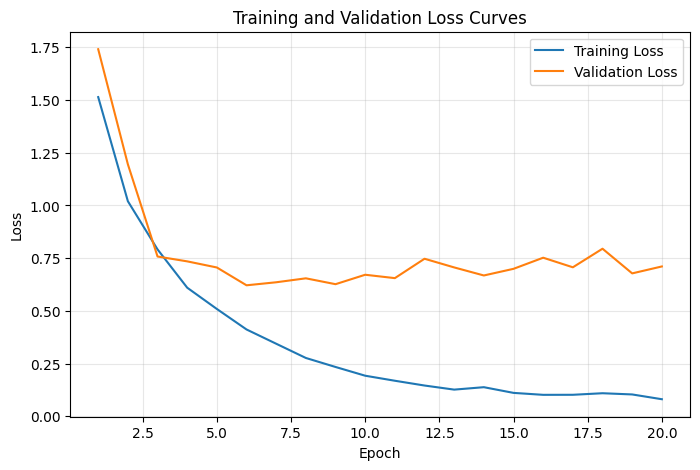

In [38]:
import matplotlib.pyplot as plt
# plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
#  testing 
model.eval()
with torch.inference_mode():
    correct = 0
    total = 0
    for images, labels in test_loader:
        if device.type == 'cuda':
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
        else:
            images = images.to(device)
            labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    print('Accuracy of the network on the {} test images: {} %'.format(len(test_loader.dataset), 100 * correct / total))

Accuracy of the network on the 10000 test images: 80.82 %
